# MalthusJAX Benchmark Analysis
VERY IMPORTANT: each row in the data represents 30 runs with 30 different seeds, hence the evarage and the std in every line, each derived statistic is taking this into account


## Hierarchical Analysis: Global → Task-Specific → Parameter Sensitivity

This notebook provides a structured analysis of MalthusJAX vs Evosax benchmarks across multiple problem classes and configurations.

**Analysis Levels:**
1. **Level 0:** Experimental Grid Overview - Enumerate design space
2. **Level 1:** Task Landscape - Compare all 5 tasks side-by-side
3. **Level 2:** Single-Task Deep Dive - Arbitrary task analysis (2×2 panels)
4. **Level 3:** Parameter Sensitivity - Heatmaps and optimal configs
5. **Legacy:** Original aggregate analysis (figures & tables)

In [1]:
import os
import sys
import glob
import importlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Add results to path for importing artifact_generation
sys.path.insert(0, os.path.abspath('results'))

# Import artifact generation module
import artifact_generation as ag

# Reload to get latest changes
importlib.reload(ag)

print(f"Artifact generation module loaded from: {ag.__file__}")

Artifact generation module loaded from: /Users/leonardodicaterina/Documents/GitHub/MalthusJAX/results/artifact_generation.py


# 1. Data Loading

Description: Load the raw CSV benchmark files collected from the NVIDIA A100 experiments and concatenate them into a single master dataset.

Notes / Implementation checklist:
- Files are read from the `speedup_test_run/` directory (pattern `speedup_test_run/*.csv`) and concatenated via `pd.concat`.
- Handle missing or unreadable files gracefully (print a warning and skip).
- Expected columns: `Algorithm, Task, Dim, Pop_Size, Unroll, Gens, Framework, Mean_GPS, Mean_Time, Std_Time, Compile_Time, Best_Fitness, Fitness_Std, Normalized_Fitness`.
- checks to run after loading:
    - `df.info()` and `df.head()` for basic integrity
    - `df['Framework'].unique()` and `df['Task'].unique()` for expected values
    - Validate numeric ranges (e.g., `Mean_GPS > 0`, `Unroll` ∈ {1,25,50})
    - Check for duplicate rows or inconsistent Pop_Size values
- Do not overwrite the raw `df`; derive summaries (e.g., `df_peak`, `df_pivot`) for downstream analysis:
    - `df_peak`: best `Mean_GPS` per `(Task, Dim, Pop_Size, Condition)` (max over `Unroll`)
    - `df_pivot`: wide table to compute speedups between conditions
- Reproducibility: print loaded file count and sample file names; keep the file-list sorted to ensure deterministic loading order.

# Paper Artifact Generation

This section uses the artifact generation module to create publication-ready figures and tables.

**Available Functions:**

**Core Data Functions:**
- `load_data(path)` - Load and concatenate benchmark CSVs with Condition mapping

**Statistical Functions:**
- `calculate_cohens_d_aggregate(m1, std1, n1, m2, std2, n2)` - Cohen's d effect size
- `aggregate_summary_stats(df, group_cols, mean_col, std_col)` - Aggregate with variance pooling
- `add_standardized_fitness(df)` - Normalize fitness against baseline
- `calculate_welch_t_aggregate(m1, std1, n1, m2, std2, n2)` - Welch's t-test
- `calculate_grand_mean_ci(df, mean_col, std_col, confidence)` - Grand mean with CI
- `compute_robust_speedup_stats(df, baseline_cond, target_cond)` - Comprehensive speedup analysis
- `compute_robust_cohens_d(df_agg, target_cond, baseline_cond, metric_mean, metric_std)` - Effect size for aggregated data

**Plot Functions (all have plot_it=False, save_it=True):**
- `plot_robust_single_task_analysis(df, task, plot_it, save_it)` - 2×2 deep dive for single task
- `plot_spotless_task_landscape(df, plot_it, save_it)` - All tasks side-by-side comparison
- `plot_speedup_heatmap(df, task, plot_it, save_it)` - Pop_Size × Dimension speedup grid
- `plot_global_broad_view_speedup(df, baseline, target, plot_it, save_it)` - Speedup vs Pop_Size
- `plot_warp_penalty_sensitivity(df, target_cond, plot_it, save_it)` - Warp penalty across tasks/unrolls
- `plot_spotless_fig4_fidelity(df, plot_it, save_it)` - Algorithmic fidelity (fitness distributions)
- `plot_absolute_warp_exposure(df, plot_it, save_it)` - N=1024 vs N=1025 throughput
- `plot_fig5_unroll_impact(df, plot_it, save_it)` - Unroll factor impact across tasks

**Table Functions (all have display_it=False, save_it=True, return_latex=False):**
- `generate_spotless_task_summary(df, task, display_it, save_it, return_latex)` - Per-task regime performance
- `generate_empirical_parity_latex(df, display_it, save_it, return_latex)` - Fitness quality comparison
- `generate_spotless_landscape_table(df, baseline_cond, target_cond, display_it, save_it, return_latex)` - Global landscape summary
- `generate_speedup_latex_table(df, task, baseline, target, display_it, save_it, return_latex)` - Speedup grid with stats
- `generate_broad_view_latex_table(df, baseline, target, display_it, save_it, return_latex)` - Global speedup by Pop_Size
- `generate_fidelity_stats_table(df, display_it, save_it, return_latex)` - Mann-Whitney U tests
- `generate_warp_sensitivity_latex(df, target_cond, display_it, save_it, return_latex)` - Warp penalty statistics

## Load Data Using Artifact Module

Use the standardized `load_data` function which automatically adds the `Condition` column.

In [2]:
# Check directory existence (use correct relative path)
data_path = 'speedup_test_run/'
print(f"Directory exists: {os.path.exists(data_path)}")
print(f"Is directory: {os.path.isdir(data_path)}")

# List all files in the directory
if os.path.exists(data_path):
    all_files = os.listdir(data_path)
    print(f"\nAll files in {data_path}:")
    for f in sorted(all_files)[:10]:  # Show first 10 files
        print(f"  - {f}")
    
    # Check for CSV files with any pattern
    csv_files = glob.glob(os.path.join(data_path, "*.csv"))
    print(f"\nCSV files found: {len(csv_files)}")
    
    # Check the expected pattern
    pattern_files = glob.glob(os.path.join(data_path, "final_benchmark_*.csv"))
    print(f"Files matching 'final_benchmark_*.csv': {len(pattern_files)}")
else:
    print(f"✗ Directory {data_path} not found!")

print(f"\nCurrent working directory: {os.getcwd()}")

Directory exists: True
Is directory: True

All files in speedup_test_run/:
  - .DS_Store
  - final_benchmark_20260108_190719.csv
  - final_benchmark_20260108_202929.csv
  - final_benchmark_20260108_214351.csv
  - final_benchmark_20260108_231104.csv
  - final_benchmark_20260109_003001.csv
  - final_benchmark_20260109_235146.csv
  - final_benchmark_20260110_010629.csv
  - final_benchmark_20260110_021200.csv
  - final_benchmark_20260110_032553.csv

CSV files found: 15
Files matching 'final_benchmark_*.csv': 15

Current working directory: /Users/leonardodicaterina/Documents/GitHub/MalthusJAX/results


In [ ]:
df_raw = ag.load_data(path='speedup_test_run/')

print(f"Raw data shape: {df_raw.shape}")
print(f"Conditions available: {sorted(df_raw['Condition'].unique())}")
print(f"Tasks available: {sorted(df_raw['Task'].unique())}")

Raw data shape: (1080, 15)
Conditions available: ['Evosax', 'MalthusJAX (Ablation)', 'MalthusJAX (Static)']
Tasks available: ['ellipsoidal_rotated', 'rastrigin', 'rosenbrock', 'schaffers_f7', 'sphere']


In [4]:
df_raw.head()

,Algorithm,Task,Dim,Pop_Size,Unroll,Gens,Framework,Mean_GPS,Mean_Time,Std_Time,Compile_Time,Best_Fitness,Fitness_Std,Normalized_Fitness,Condition
0,Standard_GA,rastrigin,20,128,1,2000,MalthusJAX,29263.597093,0.068344,0.000333,1.350447,-122.178112,18.414646,122.178112,MalthusJAX (Static)
1,Standard_GA,rastrigin,20,128,1,2000,Evosax,6309.315545,0.316992,0.010448,1.373105,-35.750326,9.676406,35.750326,Evosax
2,Standard_GA,rastrigin,20,128,25,2000,MalthusJAX,38261.609038,0.052272,0.000914,52.986085,-122.178112,18.414646,122.178112,MalthusJAX (Static)
3,Standard_GA,rastrigin,20,128,25,2000,Evosax,6918.421716,0.289083,0.003427,27.205742,-35.750326,9.676406,35.750326,Evosax
4,Standard_GA,rastrigin,20,128,50,2000,MalthusJAX,29502.662873,0.067790,0.002085,119.233278,-122.178112,18.414646,122.178112,MalthusJAX (Static)


## Generate Figures

Generate all publication-ready figures. These are saved to the `paper_artifacts/` directory.

In [5]:
ag.generate_speedup_latex_table(df_raw, task='sphere')

,N,D,Baseline GPS,Target GPS,Speedup,p-value,Cohen's d
20,128,20,"7,094","37,575",5.30x,< 0.001,22750325.85
21,128,50,"7,038","42,766",6.08x,< 0.001,16182611.88
22,129,20,"6,643","52,192",7.86x,< 0.001,26722492.55
23,129,50,"6,810","52,203",7.67x,< 0.001,16226761.57
18,1024,20,"4,907","30,959",6.31x,< 0.001,12939172.37
19,1024,50,"4,928","36,894",7.49x,< 0.001,11374812.99
15,1025,20,"4,811","25,959",5.40x,< 0.001,15074196.72
17,1025,50,"4,820","30,522",6.33x,< 0.001,13188694.52
14,2048,20,"4,341","25,343",5.84x,< 0.001,14119461.89
16,2048,50,"4,345","26,895",6.19x,< 0.001,9167147.24


### Figure 1: Throughput Comparison


In [6]:
ag.plot_global_broad_view_speedup(df_raw)

In [7]:
ag.generate_broad_view_latex_table(df_raw)

,Pop. Size ($N$),Regime,Mean Speedup,95\% CI,Configs ($k$)
0,128,Latency-Bound,6.00x,$\pm$0.60,30
1,129,Latency-Bound,6.19x,$\pm$0.46,30
2,1024,Latency-Bound,6.72x,$\pm$0.34,30
3,1025,Throughput-Bound,5.80x,$\pm$0.23,30
4,2048,Throughput-Bound,6.04x,$\pm$0.27,30
5,2049,Throughput-Bound,5.29x,$\pm$0.21,30
6,4096,Throughput-Bound,4.71x,$\pm$0.16,30
7,4097,Throughput-Bound,4.04x,$\pm$0.11,30
8,8192,Throughput-Bound,4.23x,$\pm$0.11,30
9,8193,Throughput-Bound,3.60x,$\pm$0.07,30


### Figure 2: Speedup Factor


### Figure 3: Warp Alignment Penalty

In [8]:
ag.plot_absolute_warp_exposure(df_raw)

    ('Evosax', 'Standard_GA'): 'Evosax',
    ('MalthusJAX', 'Standard_GA'): 'MalthusJAX (Static)',
    ('MalthusJAX', 'Standard_GA_Ablation'): 'MalthusJAX (Ablation)',

In [9]:
ag.generate_warp_sensitivity_latex(df_raw, target_cond= 'Evosax')

,Task,Aligned GPS,Misaligned GPS,Penalty ($\tau$),95\% CI,Cohen's $d$
0,Ellipsoidal Rotated,"4,725","4,599",2.68\%,$\pm$0.00\%,37775.52
1,Rastrigin,"4,677","4,548",2.76\%,$\pm$0.00\%,38395.32
2,Rosenbrock,"4,662","4,633",0.61\%,$\pm$0.00\%,10230.45
3,Schaffers F7,"4,537","4,442",2.08\%,$\pm$0.00\%,28314.36
4,Sphere,"4,820","4,684",2.82\%,$\pm$0.00\%,38440.96


### Figure 4: Unroll Impact

In [11]:
df_raw[(df_raw['Condition'] == 'Evosax') & (df_raw['Task'] == 'rosenbrock')]

,Algorithm,Task,Dim,Pop_Size,Unroll,Gens,Framework,Mean_GPS,Mean_Time,Std_Time,Compile_Time,Best_Fitness,Fitness_Std,Normalized_Fitness,Condition
109,Standard_GA,rosenbrock,20,128,1,2000,Evosax,6393.364694,0.312824,0.002060,1.188020,909.932214,197.767182,909.932214,Evosax
111,Standard_GA,rosenbrock,20,128,25,2000,Evosax,6666.070263,0.300027,0.001477,25.444822,909.932214,197.767182,909.932214,Evosax
113,Standard_GA,rosenbrock,20,128,50,2000,Evosax,6262.732951,0.319349,0.002999,51.580476,909.932214,197.767182,909.932214,Evosax
115,Standard_GA,rosenbrock,20,129,1,2000,Evosax,6323.480556,0.316282,0.002088,1.150012,848.005733,238.322961,848.005733,Evosax
117,Standard_GA,rosenbrock,20,129,25,2000,Evosax,6428.852640,0.311098,0.001136,25.205339,848.005733,238.322961,848.005733,Evosax
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1059,Standard_GA,rosenbrock,50,2049,1,2000,Evosax,3884.497300,0.514867,0.003147,1.433653,337449.114063,43003.064094,337449.114063,Evosax
1061,Standard_GA,rosenbrock,50,4096,1,2000,Evosax,3481.742672,0.574425,0.003087,1.441465,320805.060937,40290.122559,320805.060937,Evosax
1063,Standard_GA,rosenbrock,50,4097,1,2000,Evosax,3221.496919,0.620829,0.003156,1.519513,319512.243750,31198.015206,319512.243750,Evosax
1065,Standard_GA,rosenbrock,50,8192,1,2000,Evosax,3044.754624,0.656867,0.002788,1.560822,297579.847917,35059.776302,297579.847917,Evosax


[5/9] Figure 5: Unroll Factor Impact


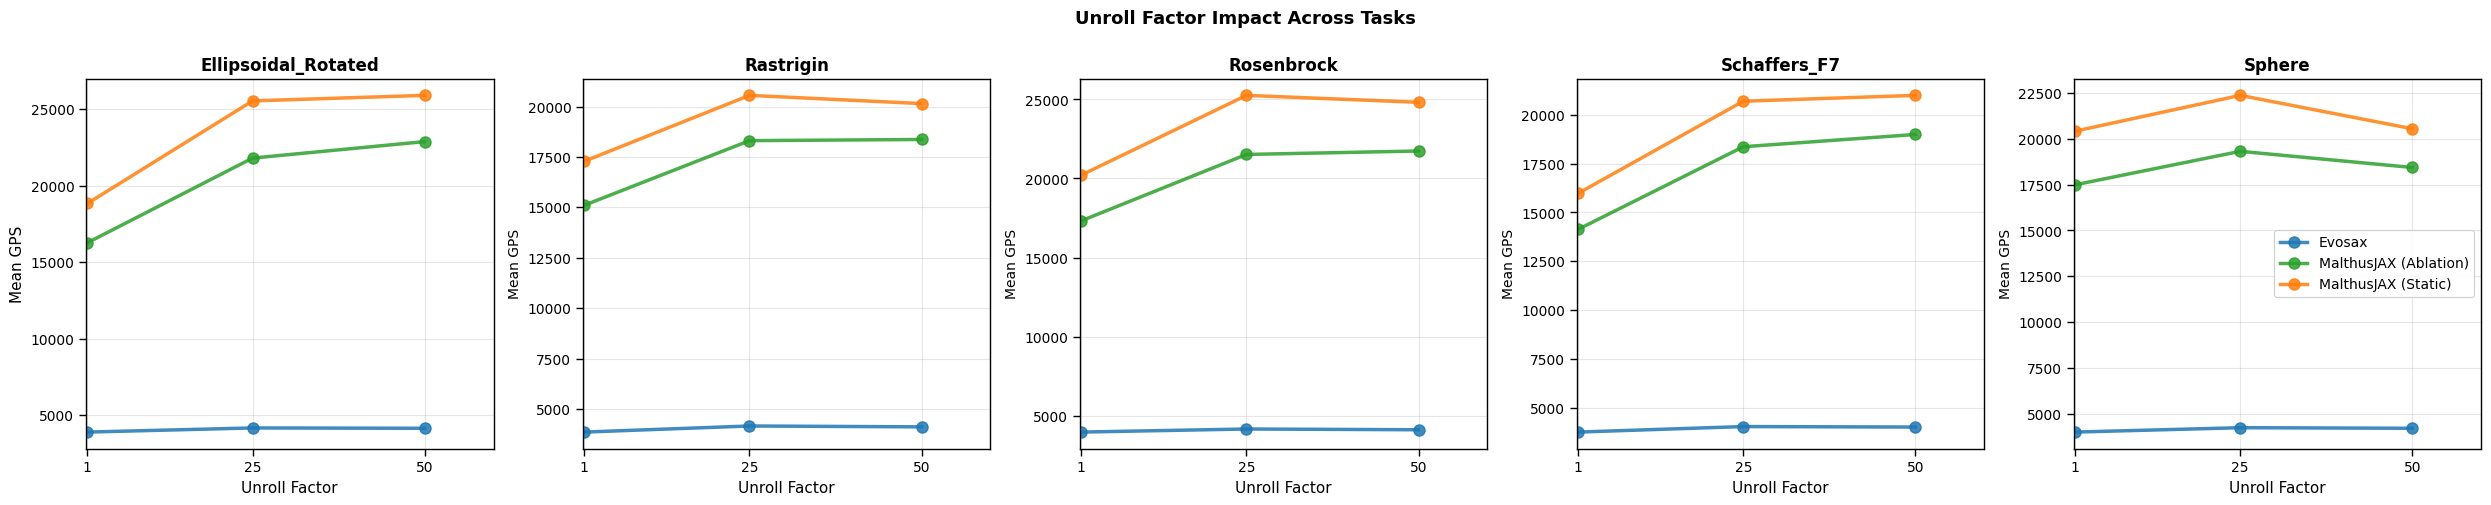

In [12]:
print("[5/9] Figure 5: Unroll Factor Impact")
ag.plot_fig5_unroll_impact(df_raw, plot_it=True, save_it=False)

## LEVEL 0: Experimental Grid Overview
*Understand the design space and task metadata*

In [13]:
# Display basic experimental grid info
print("="*60)
print("EXPERIMENTAL DESIGN SPACE")
print("="*60)
print(f"Total rows: {len(df_raw):,}")
print(f"\nConditions: {sorted(df_raw['Condition'].unique())}")
print(f"Tasks: {sorted(df_raw['Task'].unique())}")
print(f"Dimensions: {sorted(df_raw['Dim'].unique())}")
print(f"Population Sizes: {sorted(df_raw['Pop_Size'].unique())}")
print(f"Unroll Factors: {sorted(df_raw['Unroll'].unique())}")
print(f"Generations: {sorted(df_raw['Gens'].unique())}")

# Task metadata
print("\n" + "="*60)
print("TASK METADATA & LANDSCAPE CHARACTERISTICS")
print("="*60)
task_metadata_rows = []
for task, info in ag.TASK_METADATA.items():
    task_metadata_rows.append({
        'Task': task.title(),
        'Modality': info['modality'].title(),
        'Separability': info['separability'].title(),
        'Difficulty': info['difficulty'].title(),
        'Description': info['description']
    })

df_task_metadata = pd.DataFrame(task_metadata_rows)
print(df_task_metadata.to_string(index=False))

EXPERIMENTAL DESIGN SPACE
Total rows: 1,080

Conditions: ['Evosax', 'MalthusJAX (Ablation)', 'MalthusJAX (Static)']
Tasks: ['ellipsoidal_rotated', 'rastrigin', 'rosenbrock', 'schaffers_f7', 'sphere']
Dimensions: [np.int64(20), np.int64(50)]
Population Sizes: [np.int64(128), np.int64(129), np.int64(1024), np.int64(1025), np.int64(2048), np.int64(2049), np.int64(4096), np.int64(4097), np.int64(8192), np.int64(8193), np.int64(16384), np.int64(16385)]
Unroll Factors: [np.int64(1), np.int64(25), np.int64(50)]
Generations: [np.int64(2000)]

TASK METADATA & LANDSCAPE CHARACTERISTICS
      Task   Modality  Separability Difficulty       Description
    Sphere   Unimodal     Separable       Easy   Convex, trivial
Rosenbrock   Unimodal Non-Separable     Medium  Valley, moderate
 Rastrigin Multimodal     Separable       Hard Many local optima
  Griewank Multimodal Non-Separable     Medium Product structure
    Ackley Multimodal Non-Separable       Hard     Narrow valley


## LEVEL 1: Task Landscape Analysis
*Side-by-side comparison of all 5 benchmark tasks*

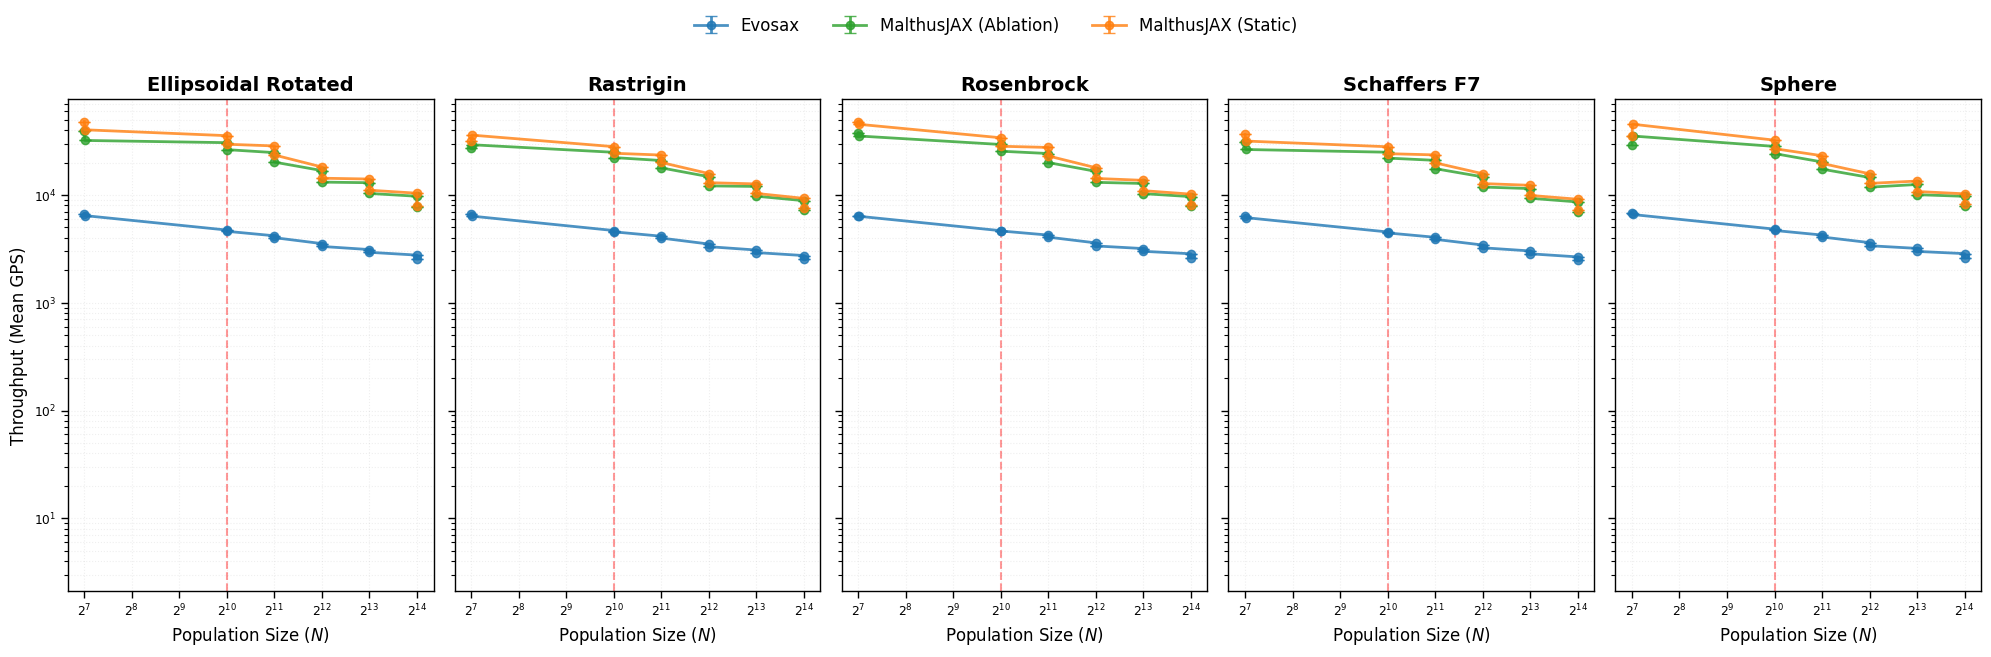

In [14]:
ag.plot_spotless_task_landscape(df_raw, plot_it=True, save_it=False)

## LEVEL 2: Single-Task Deep Dive
*Select a task and analyze in detail with 2×2 panel breakdown*

**Select task below (sphere, rosenbrock, rastrigin, griewank, ackley):**

In [15]:
# MODIFY THIS: select which task to analyze
selected_task = 'sphere'

# 2x2 deep dive analysis TODO: make this better
#ag.plot_robust_single_task_analysis(df_raw, task=selected_task, plot_it=True, save_it=False)

# Task summary table
print(f"\n{'='*60}")
print(f"TASK SUMMARY: {selected_task.upper()}")
print(f"{'='*60}\n")
ag.generate_spotless_task_summary(df_raw, task=selected_task, display_it=True, save_it=False)


TASK SUMMARY: SPHERE


Spotless Summary for Sphere Task:
            Condition     Regime Mean GPS           95% CI Rel. Fitness
               Evosax    Latency    6,093   [5,619, 6,566]        1.003
MalthusJAX (Ablation)    Latency   30,873 [28,046, 33,699]        1.202
  MalthusJAX (Static)    Latency   37,486 [33,055, 41,917]        1.202
               Evosax Throughput    3,518   [3,335, 3,700]        1.000
MalthusJAX (Ablation) Throughput   14,256 [12,808, 15,703]        1.202
  MalthusJAX (Static) Throughput   15,643 [13,942, 17,344]        1.202


'\\begin{table}\n\\caption{Regime Performance: SPHERE}\n\\label{tab:task_sphere}\n\\begin{tabular}{lllll}\n\\toprule\nCondition & Regime & Mean GPS & 95% CI & Rel. Fitness \\\\\n\\midrule\nEvosax & Latency & 6,093 & [5,619, 6,566] & 1.003 \\\\\nMalthusJAX (Ablation) & Latency & 30,873 & [28,046, 33,699] & 1.202 \\\\\nMalthusJAX (Static) & Latency & 37,486 & [33,055, 41,917] & 1.202 \\\\\nEvosax & Throughput & 3,518 & [3,335, 3,700] & 1.000 \\\\\nMalthusJAX (Ablation) & Throughput & 14,256 & [12,808, 15,703] & 1.202 \\\\\nMalthusJAX (Static) & Throughput & 15,643 & [13,942, 17,344] & 1.202 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

In [16]:
ag.generate_empirical_parity_latex(df_raw)

Framework                    Evosax                   MalthusJAX (Ablation)  \
                             95% CI Mean Best Fitness                95% CI   
Task                                                                          
Ellipsoidal Rotated  $\pm$ 2.70e+05          1.19e+06        $\pm$ 2.40e+03   
Rastrigin            $\pm$ 1.32e+02          4.48e+02        $\pm$ 2.90e+01   
Rosenbrock           $\pm$ 3.12e+04          8.67e+04        $\pm$ 6.91e+00   
Schaffers F7         $\pm$ 1.38e+00         -1.86e+02        $\pm$ 4.58e-01   
Sphere               $\pm$ 2.29e+01         -1.12e+02        $\pm$ 3.61e-02   

Framework                             MalthusJAX (Static)                    
                    Mean Best Fitness              95% CI Mean Best Fitness  
Task                                                                         
Ellipsoidal Rotated          1.22e+04      $\pm$ 2.36e+03          1.20e+04  
Rastrigin                   -3.16e+01      $\pm$ 2.89e+01         -3.17e+01  
Rosenbrock                  -1.39e+02      $\pm$ 7.52e+00         -1.38e+02  
Schaffers F7                -1.92e+02      $\pm$ 4.71e-01         -1.92e+02  
Sphere                      -1.94e+02      $\pm$ 3.61e-02         -1.94e+02

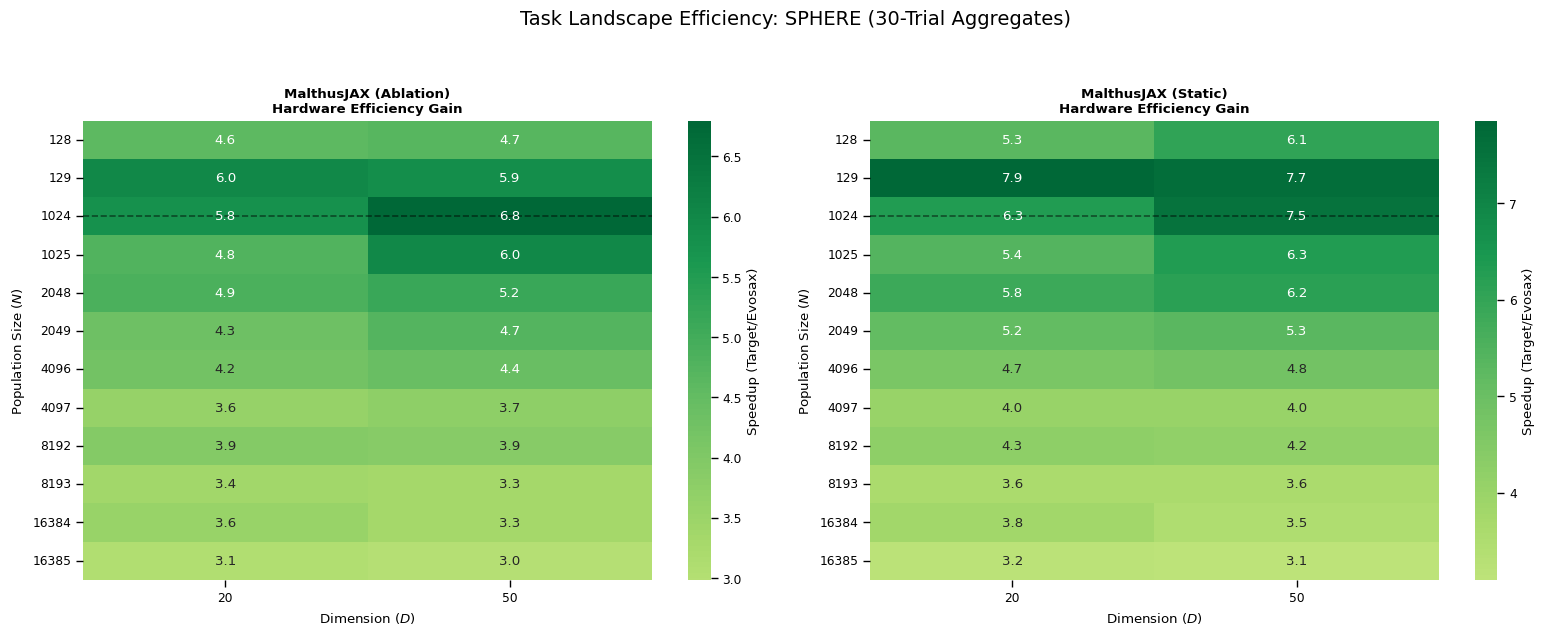

In [17]:
# Speedup heatmap for selected task
ag.plot_speedup_heatmap(df_raw, task=selected_task, plot_it=True, save_it=False)

## LEVEL 3: Custom Data Queries
*Filter and aggregate data for custom analysis*

Use pandas filtering and groupby operations for flexible analysis.

In [18]:
# Example 1: Compare Sphere vs Rosenbrock performance at Pop=2048
result = df_raw[(df_raw['Task'].isin(['sphere', 'rosenbrock'])) & (df_raw['Pop_Size'] == 2048)]
summary = result.groupby(['Task', 'Condition'])['Mean_GPS'].mean().reset_index()
print("\nPerformance comparison at Pop=2048:")
print(summary.to_string(index=False))


Performance comparison at Pop=2048:
      Task             Condition     Mean_GPS
rosenbrock                Evosax  4244.682463
rosenbrock MalthusJAX (Ablation) 24228.009420
rosenbrock   MalthusJAX (Static) 27588.796968
    sphere                Evosax  4246.676113
    sphere MalthusJAX (Ablation) 20233.581668
    sphere   MalthusJAX (Static) 23109.603276


In [19]:
# Example 2: Unroll factor sensitivity for high-dimensional sphere
high_dim = df_raw[(df_raw['Task'] == 'sphere') & (df_raw['Dim'].isin([100, 500, 1000]))]
unroll_summary = high_dim.groupby(['Unroll', 'Condition'])['Mean_GPS'].mean().reset_index()
print("\nSphere high-dimensional performance by Unroll factor:")
print(unroll_summary.to_string(index=False))


Sphere high-dimensional performance by Unroll factor:
Empty DataFrame
Columns: [Unroll, Condition, Mean_GPS]
Index: []


## Additional Analysis Examples
*More visualization and table generation examples*

[Example 1] Absolute Warp Exposure


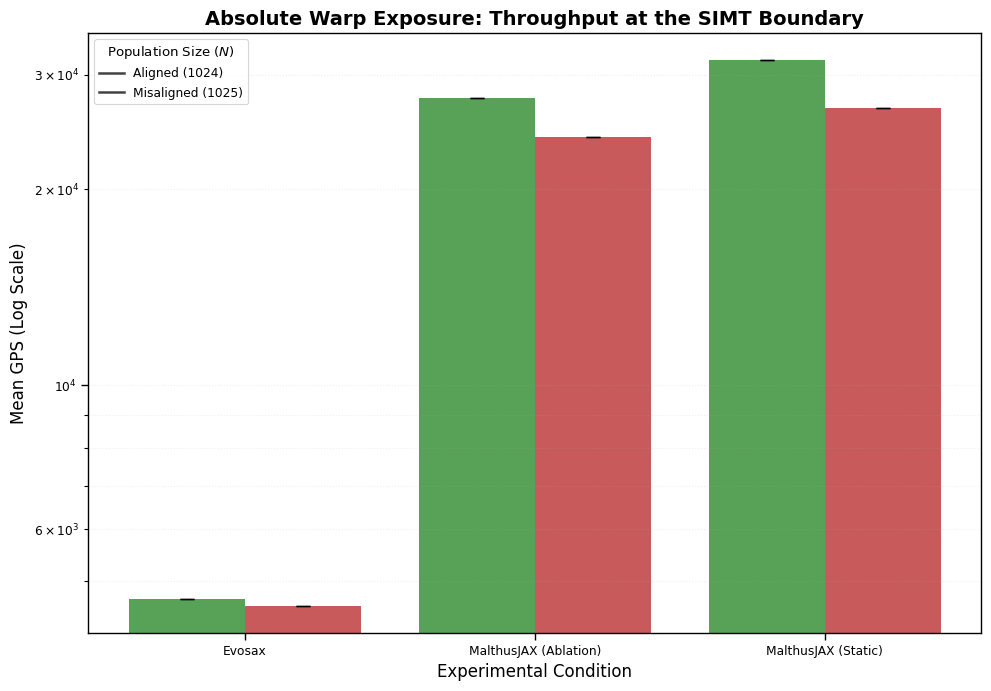

In [20]:
print("[Example 1] Absolute Warp Exposure")
ag.plot_absolute_warp_exposure(df_raw, plot_it=True, save_it=False)

In [21]:
print("[Example 2] Algorithmic Fidelity Analysis")
#TODO: make this better
#ag.plot_spotless_fig4_fidelity(df_raw, plot_it=True, save_it=False)

[Example 2] Algorithmic Fidelity Analysis


In [22]:
print("[Example 3] Empirical Parity Table")
parity_df = ag.generate_empirical_parity_latex(df_raw, display_it=True, save_it=False, return_latex=False)

[Example 3] Empirical Parity Table

Empirical Optimization Parity:
Framework                    Evosax                   MalthusJAX (Ablation)                   MalthusJAX (Static)                  
                             95% CI Mean Best Fitness                95% CI Mean Best Fitness              95% CI Mean Best Fitness
Task                                                                                                                               
Ellipsoidal Rotated  $\pm$ 2.70e+05          1.19e+06        $\pm$ 2.40e+03          1.22e+04      $\pm$ 2.36e+03          1.20e+04
Rastrigin            $\pm$ 1.32e+02          4.48e+02        $\pm$ 2.90e+01         -3.16e+01      $\pm$ 2.89e+01         -3.17e+01
Rosenbrock           $\pm$ 3.12e+04          8.67e+04        $\pm$ 6.91e+00         -1.39e+02      $\pm$ 7.52e+00         -1.38e+02
Schaffers F7         $\pm$ 1.38e+00         -1.86e+02        $\pm$ 4.58e-01         -1.92e+02      $\pm$ 4.71e-01         -1.92e+02
Sphere   

[Example 4] Warp Penalty Sensitivity


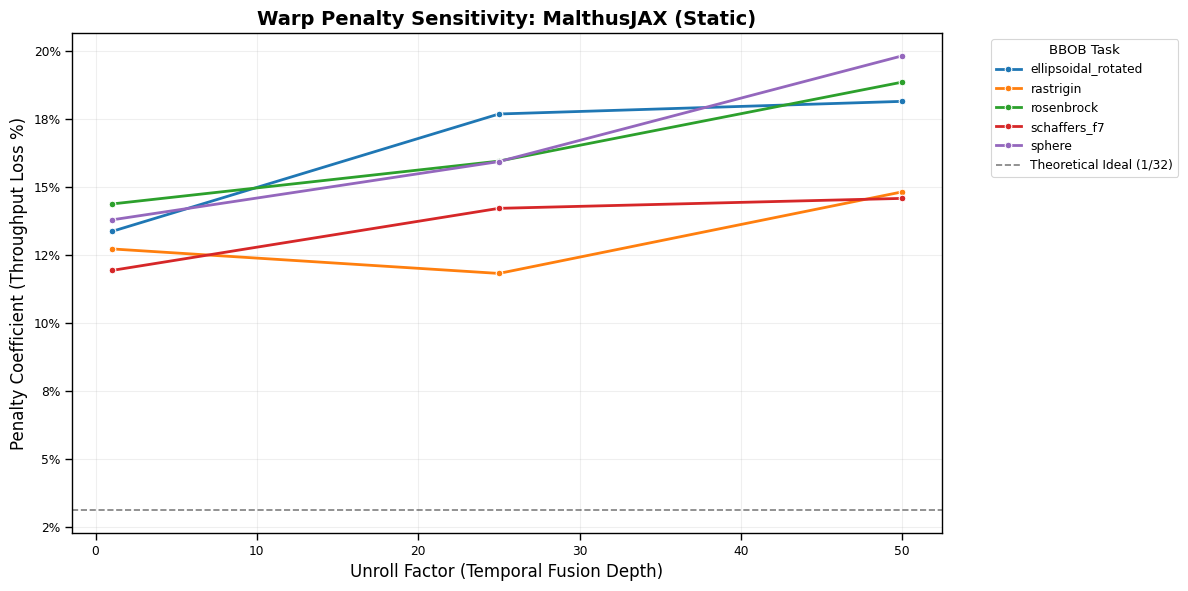

In [23]:
print("[Example 4] Warp Penalty Sensitivity")
ag.plot_warp_penalty_sensitivity(df_raw, plot_it=True, save_it=False)

In [24]:
print("[Example 5] Global Landscape Table")
landscape_df = ag.generate_spotless_landscape_table(df_raw, display_it=True, save_it=False, return_latex=False)
print("\n" + "="*60)
print("\n[Example 6] Fidelity Statistics Table")
fidelity_df = ag.generate_fidelity_stats_table(df_raw, display_it=True, save_it=False, return_latex=False)
print("\n" + "="*60)
print("\n[Example 7] Warp Sensitivity Table")
warp_df = ag.generate_warp_sensitivity_latex(df_raw, display_it=True, save_it=False, return_latex=False)
print("\n" + "="*60)
print("\n[Example 8] Broad View Speedup Table")
speedup_df = ag.generate_broad_view_latex_table(df_raw, display_it=True, save_it=False, return_latex=False)



[Example 5] Global Landscape Table

Global Performance Landscape:
               Task     Regime Baseline Mean Target Mean ± 95% CI Speedup Cohen's d
Ellipsoidal Rotated    Latency         5,957           41,239 ± 0   6.92x       nan
Ellipsoidal Rotated Throughput         3,450           17,492 ± 0   5.07x       nan
          Rastrigin    Latency         5,898           31,838 ± 0   5.40x       nan
          Rastrigin Throughput         3,419           15,157 ± 0   4.43x       nan
         Rosenbrock    Latency         5,816           42,388 ± 0   7.29x       nan
         Rosenbrock Throughput         3,505           17,109 ± 0   4.88x       nan
       Schaffers F7    Latency         5,711           32,047 ± 0   5.61x       nan
       Schaffers F7 Throughput         3,337           14,951 ± 0   4.48x       nan
             Sphere    Latency         6,093           37,486 ± 0   6.15x       nan
             Sphere Throughput         3,518           15,643 ± 0   4.45x       nan


[Example

### Summary: Generated Artifacts

All artifacts are saved to `results/figures_tables/` when `save_it=True`:

**Figures (PNG):**
- `spotless_task_landscape.png` - All 5 tasks side-by-side comparison
- `spotless_analysis_{task}.png` - 2×2 deep dive per task
- `speedup_heatmap_{task}.png` - Pop_Size × Dimension speedup grids
- `global_speedup_broad_view.png` - Grand mean speedup vs Pop_Size
- `warp_penalty_sensitivity.png` - Warp penalty across tasks/unrolls
- `fig4_algorithmic_fidelity.png` - Fitness distribution facets
- `absolute_warp_exposure.png` - N=1024 vs N=1025 throughput bars
- `fig5_unroll_impact.png` - Unroll factor impact across tasks

**Tables (LaTeX/CSV):**
- `spotless_summary_{task}.tex/csv` - Per-task regime performance
- `empirical_parity.tex/csv` - Fitness quality comparison
- `global_landscape.tex/csv` - Global landscape summary
- `speedup_analysis_{task}.tex/csv` - Speedup grid with statistics
- `broad_view_speedup.tex/csv` - Global speedup by Pop_Size
- `fidelity_stats.tex/csv` - Mann-Whitney U test results
- `warp_sensitivity.tex/csv` - Warp penalty statistics

In [25]:
# Verify output directory was created
import os
if os.path.exists(ag.OUTPUT_DIR):
    artifacts = os.listdir(ag.OUTPUT_DIR)
    print(f"Generated {len(artifacts)} artifacts in {ag.OUTPUT_DIR}")
else:
    print(f"Output directory {ag.OUTPUT_DIR} not yet created")

Generated 7 artifacts in results/figures_tables/


In [26]:
# Example: Analyze warp alignment boundary effect
print("--- WARP ALIGNMENT BOUNDARY ANALYSIS ---\n")

# Define the warp-alignment pairs (N vs N+1)
pairs = [(128, 129), (1024, 1025), (16384, 16385)]

alignment_results = []

for condition in df_raw['Condition'].unique():
    for aligned, misaligned in pairs:
        # Filter for the specific population sizes
        val_aligned = df_raw[(df_raw['Condition'] == condition) & 
                             (df_raw['Pop_Size'] == aligned)]['Mean_GPS'].mean()
        val_misaligned = df_raw[(df_raw['Condition'] == condition) & 
                                (df_raw['Pop_Size'] == misaligned)]['Mean_GPS'].mean()
        
        if pd.notnull(val_aligned) and pd.notnull(val_misaligned):
            # Calculate the penalty/delta
            delta_pct = ((val_misaligned - val_aligned) / val_aligned) * 100
            regime = "Latency" if aligned < 1000 else "Throughput"
            
            alignment_results.append({
                'Condition': condition,
                'Regime': regime,
                'N': aligned,
                'N+1': misaligned,
                'GPS_N': f"{val_aligned:,.0f}",
                'GPS_N+1': f"{val_misaligned:,.0f}",
                'Delta (%)': f"{delta_pct:+.2f}%"
            })

# Display as a summary table
df_alignment = pd.DataFrame(alignment_results)
print(df_alignment.to_string(index=False))

--- WARP ALIGNMENT BOUNDARY ANALYSIS ---

            Condition     Regime     N   N+1  GPS_N GPS_N+1 Delta (%)
  MalthusJAX (Static)    Latency   128   129 39,791  39,669    -0.31%
  MalthusJAX (Static) Throughput  1024  1025 31,539  26,645   -15.52%
  MalthusJAX (Static) Throughput 16384 16385  9,846   7,806   -20.72%
               Evosax    Latency   128   129  6,623   6,378    -3.70%
               Evosax Throughput  1024  1025  4,684   4,581    -2.20%
               Evosax Throughput 16384 16385  2,775   2,563    -7.61%
MalthusJAX (Ablation)    Latency   128   129 33,000  31,625    -4.17%
MalthusJAX (Ablation) Throughput  1024  1025 27,586  24,031   -12.88%
MalthusJAX (Ablation) Throughput 16384 16385  9,311   7,535   -19.08%


In [27]:
# Example: Aggregated statistics for publication-ready tables
print("--- STATISTICS ---\n")

# 1. Warp Alignment Statistics with Error Bars
pairs = [(128, 129), (1024, 1025), (16384, 16385)]
alignment_stats = []

for condition in ['Evosax', 'MalthusJAX (Static)']:
    for aligned, misaligned in pairs:
        # Filter data
        d_a = df_raw[(df_raw['Condition'] == condition) & (df_raw['Pop_Size'] == aligned)]
        d_m = df_raw[(df_raw['Condition'] == condition) & (df_raw['Pop_Size'] == misaligned)]
        
        if not d_a.empty and not d_m.empty:
            # Calculate mean and std for GPS
            mean_a, std_a = d_a['Mean_GPS'].mean(), d_a['Mean_GPS'].std()
            mean_m, std_m = d_m['Mean_GPS'].mean(), d_m['Mean_GPS'].std()
            delta = ((mean_m - mean_a) / mean_a) * 100
            
            alignment_stats.append({
                'Condition': condition,
                'N': aligned,
                'GPS_N': f"{mean_a:,.0f} ± {std_a:.1f}",
                'GPS_N+1': f"{mean_m:,.0f} ± {std_m:.1f}",
                'Delta': f"{delta:+.2f}%"
            })

print("Warp Alignment Impact:")
print(pd.DataFrame(alignment_stats).to_string(index=False))

# 2. Fitness Parity Check (Ablation vs Static)
print("\n\nAlgorithmic Fidelity (Fitness Comparison at N=1024):")
fidelity_comparison = []
for task in df_raw['Task'].unique():
    for cond in ['Evosax', 'MalthusJAX (Static)', 'MalthusJAX (Ablation)']:
        subset = df_raw[(df_raw['Task'] == task) & 
                       (df_raw['Condition'] == cond) & 
                       (df_raw['Pop_Size'] == 1024)]
        if not subset.empty:
            fidelity_comparison.append({
                'Task': task.title(),
                'Condition': cond,
                'Mean_Fitness': f"{subset['Best_Fitness'].mean():.2e}",
                'Std_Fitness': f"{subset['Best_Fitness'].std():.2e}"
            })

print(pd.DataFrame(fidelity_comparison).to_string(index=False))

--- STATISTICS ---

Warp Alignment Impact:
          Condition     N            GPS_N         GPS_N+1   Delta
             Evosax   128    6,623 ± 278.8   6,378 ± 268.5  -3.70%
             Evosax  1024    4,684 ± 159.1   4,581 ± 180.6  -2.20%
             Evosax 16384    2,775 ± 106.7    2,563 ± 96.8  -7.61%
MalthusJAX (Static)   128 39,791 ± 11381.5 39,669 ± 9194.9  -0.31%
MalthusJAX (Static)  1024  31,539 ± 5122.3 26,645 ± 3749.3 -15.52%
MalthusJAX (Static) 16384   9,846 ± 1103.5   7,806 ± 780.1 -20.72%


Algorithmic Fidelity (Fitness Comparison at N=1024):
               Task             Condition Mean_Fitness Std_Fitness
          Rastrigin                Evosax     2.04e+02    2.83e+02
          Rastrigin   MalthusJAX (Static)    -1.05e+02    7.23e+01
          Rastrigin MalthusJAX (Ablation)    -1.05e+02    7.19e+01
         Rosenbrock                Evosax     1.25e+04    1.31e+04
         Rosenbrock   MalthusJAX (Static)    -1.33e+02    4.40e+01
         Rosenbrock MalthusJAX 